In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import os
from pathlib import Path

In [10]:
image_path='../output_videos/cropped_img_1.jpg'
image=cv2.imread(image_path)
image=cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

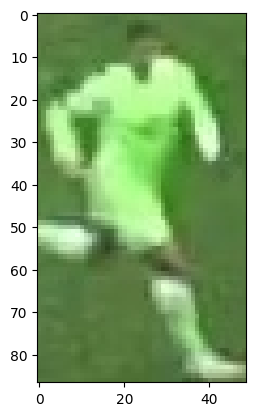

In [11]:
plt.imshow(image)
plt.show()

# take the top of the image

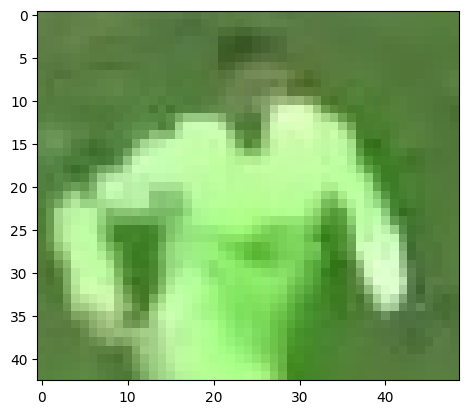

In [12]:
top_half_image= image[0:int(image.shape[0]//2), :]
plt.imshow(top_half_image)
plt.show()

# cluster the image into two clusters 

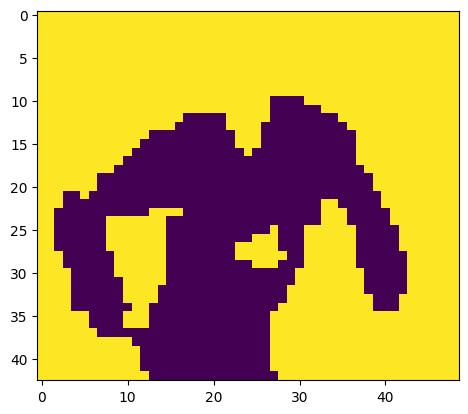

In [ ]:
# Reshape the image into 2d array
image_2d= top_half_image.reshape(-1, 3)


# Perform k-means clustering with 2 clusters
kmeans= KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)


# get the clustered labels
labels= kmeans.labels_

# reshape the labels into the original image shape
clustered_image= labels.reshape(top_half_image.shape[0], top_half_image.shape[1])
#display the clustered image
plt.imshow(clustered_image)
plt.show()

In [15]:
corner_clusters = [clustered_image[0, 0], clustered_image[0, -1], clustered_image[-1, 0], clustered_image[-1, -1]]
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)
print(f"Non-player cluster: {non_player_cluster}")

Non-player cluster: 1


In [16]:
player_cluster= 1 - non_player_cluster
print(f"Player cluster: {player_cluster}")

Player cluster: 0


In [17]:
kmeans.cluster_centers_[player_cluster]

array([171.52380952, 235.9047619 , 143.33197279])